# Section 1 - Environment set up

In [5]:
import pandas as pd
import numpy as np
import os

# Import necessary libraries for machine learning and evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import shap
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt

# Set up directories for data and results
DATA_DIR = os.path.join("..", "data", "processed")
RESULTS_DIR = os.path.join("..", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load the cleaned datasets
salminen = pd.read_csv(os.path.join(DATA_DIR, "salminen_clean.csv"))
hollenbeck = pd.read_csv(os.path.join(DATA_DIR, "hollenbeck_clean.csv"))


# Section 2 - Train + score 4 models

In [6]:
# SECTION 2: train + score 4 models

# Define a function to run the machine learning pipeline
def run_pipeline(df, text_col, label_col, class_weight=None, scale_pos_weight=1):
    train_x, test_x, train_y, test_y = train_test_split(
        df[text_col], df[label_col], test_size=0.2, random_state=42, stratify=df[label_col]
    ) # Split the dataset into training and testing sets with stratification to maintain class distribution

    # Convert  text (_x) into numeric features (_v)
    tfidf = TfidfVectorizer(max_features=5000, stop_words='english') # Create a TF-IDF vectorizer with a maximum of 5000 features and English stop words
    train_v = tfidf.fit_transform(train_x) 
    test_v = tfidf.transform(test_x) 

    # Define a dictionary of models to be trained and evaluated
    models = {
        'LogisticRegression': LogisticRegression(max_iter=1000, class_weight=class_weight, random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=20, class_weight=class_weight, random_state=42),
        'SVM': LinearSVC(class_weight=class_weight, random_state=42, max_iter=2000),
        'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=scale_pos_weight, random_state=42),
    } 

    # Train and evaluate each model, storing the results in a dictionary
    scores = {}
    for name, model in models.items():
        model.fit(train_v, train_y)
        pred = model.predict(test_v)
        # Because SVM does not have a predict_proba method, using decision_function for SVM to get the scores for AUC calculation. 
        # Other models use predict_proba to get the probability estimates for the positive class.
        prob = model.predict_proba(test_v)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(test_v)
        scores[name] = {
            'model': model,
            'accuracy': accuracy_score(test_y, pred),
            'precision': precision_score(test_y, pred),
            'recall': recall_score(test_y, pred),
            'f1': f1_score(test_y, pred),
            'auc': roc_auc_score(test_y, prob),
        } 

    return scores, tfidf, test_x, test_v, test_y  

# Run the pipeline for both datasets and store the results
salminen_scores, salminen_tfidf, salminen_test_x, salminen_test_v, salminen_test_y = run_pipeline(
    salminen, 'text_', 'is_fake'
)

hollenbeck_scores, hollenbeck_tfidf, hollenbeck_test_x, hollenbeck_test_v, hollenbeck_test_y = run_pipeline(
    hollenbeck, 'review_text', 'is_fake', class_weight='balanced', scale_pos_weight=17.7
)

In [7]:
# Define a function to convert the scores dictionary into a  DataFrame
def scores_to_df(scores, dataset_name):
    rows = []
    for model_name, m in scores.items():
        row = {
            'dataset': dataset_name,
            'model': model_name,
            'accuracy': m['accuracy'],
            'precision': m['precision'],
            'recall': m['recall'],
            'f1': m['f1'],
            'auc': m['auc'],
        }
        rows.append(row)
    return pd.DataFrame(rows)

# Convert the scores dictionaries into DataFrames for each dataset
salminen_df = scores_to_df(salminen_scores, 'Salminen')
hollenbeck_df = scores_to_df(hollenbeck_scores, 'Hollenbeck')

# Combine the two DataFrames into a single DataFrame and round the metrics to 3 decimal places
metrics_df = pd.concat([salminen_df, hollenbeck_df], ignore_index=True)
metrics_df = metrics_df.round(3)

# Print the metrics DataFrame and save it to a CSV file in the results directory
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(RESULTS_DIR, "pipeline1_metrics_table.csv"), index=False)

   dataset              model  accuracy  precision  recall    f1   auc
  Salminen LogisticRegression     0.867      0.873   0.860 0.866 0.942
  Salminen       RandomForest     0.795      0.812   0.768 0.789 0.886
  Salminen                SVM     0.869      0.863   0.876 0.870 0.942
  Salminen            XGBoost     0.835      0.863   0.796 0.828 0.923
Hollenbeck LogisticRegression     0.816      0.200   0.819 0.322 0.892
Hollenbeck       RandomForest     0.798      0.174   0.743 0.282 0.854
Hollenbeck                SVM     0.813      0.196   0.806 0.315 0.885
Hollenbeck            XGBoost     0.808      0.185   0.757 0.297 0.866


# Section 3 - SHAP (LogReg/RF/XGBoost) + LIME (SVM)

In [8]:
# Define a function to run SHAP analysis on the models
def run_shap(scores, test_v, sample_size=1000, seed=42):
    idx = np.random.RandomState(seed).choice(test_v.shape[0], size=sample_size, replace=False) # Choose a random sample of indices from the test set for SHAP analysis
    sample = test_v[idx]
    # Compute SHAP values (TreeExplainer for RF/XGBoost, LinearExplainer for LogReg)
    # Sample is converted to a dense array for SHAP analysis for RandomForest and XGBoost, while LogisticRegression uses the sparse representation
    # RandomForest returns a 3D array (samples, features, classes), so slice class 1 (fake) to get 2D array (samples, features)
    rf_shap = shap.TreeExplainer(scores['RandomForest']['model']).shap_values(sample.toarray())[:, :, 1]
    xgb_shap = shap.TreeExplainer(scores['XGBoost']['model']).shap_values(sample.toarray())
    logreg_shap = shap.LinearExplainer(scores['LogisticRegression']['model'], test_v).shap_values(sample)

    return {
        'LogisticRegression': (logreg_shap, sample),
        'RandomForest': (rf_shap, sample),
        'XGBoost': (xgb_shap, sample),
    }

# Define a function to run LIME analysis on the SVM model
def run_lime(model, tfidf, test_x, test_y, sample_size=100, min_words=5, seed=42):
    test_x = test_x.reset_index(drop=True)
    test_y = test_y.reset_index(drop=True)   # keep true labels aligned with test_x after reset

    # Define a prediction function for LIME that takes in a list of texts, transforms them using the TF-IDF vectorizer,
    # and returns the predicted probabilities for each class
    def predict(texts):
        score = model.decision_function(tfidf.transform(texts)) # Using decision_function to get the scores for the positive class (fake) for SVM
        prob = 1 / (1 + np.exp(-score)) # Using sigmoid function to convert decision function scores to probabilities for the positive class (fake)
        return np.column_stack([1 - prob, prob]) # Return a 2D array with probabilities for both classes (genuine and fake)

    # Select a random sample of indices from the test set for LIME analysis,
    # ensuring that the selected texts have at least minimum number of words
    lengths = test_x.str.split().str.len()
    eligible = test_x.index[lengths >= min_words]
    idx = np.random.RandomState(seed).choice(eligible, size=sample_size, replace=False)

    # Explain sample instances using LIME and return the explanations with the top 10 features for each instance
    explainer = LimeTextExplainer(class_names=['genuine', 'fake'], random_state=seed)
    explanations = [explainer.explain_instance(test_x.iloc[i], predict, num_features=10) for i in idx]

    # Get the true labels and predicted probabilities for the selected indices
    true_labels = test_y.iloc[idx].tolist()
    pred_probs = [predict([test_x.iloc[i]])[0, 1] for i in idx]

    return explanations, true_labels, pred_probs

# Pick a LIME example the model got right and is confident about
def pick_confident_correct_example(true_labels, pred_probs, target_label=1):
    best_idx, best_score = None, -1 # Initialize variables to keep track of the best index and score
    for i, (label, prob) in enumerate(zip(true_labels, pred_probs)): # Iterate through the true labels and predicted probabilities
        confidence = prob if target_label == 1 else 1 - prob # Calculate the confidence score based on the target label
        predicted_label = 1 if prob >= 0.5 else 0 # Determine the predicted label based on the probability threshold of 0.5
        # Check if the predicted label matches the true label and is equal to the target label, 
        # and if the confidence is higher than the best score found so far
        if predicted_label == label == target_label and confidence > best_score:
            best_idx, best_score = i, confidence 
    return best_idx if best_idx is not None else 0 # Return the index of the most confident correct example, or 0 if none found

# Run SHAP and LIME analyses for both datasets
# Salminen dataset
salminen_shap = run_shap(salminen_scores, salminen_test_v)
salminen_lime, salminen_lime_labels, salminen_lime_probs = run_lime(
    salminen_scores['SVM']['model'], salminen_tfidf, salminen_test_x, salminen_test_y
)
salminen_example_idx = pick_confident_correct_example(salminen_lime_labels, salminen_lime_probs, target_label=1)
# Hollenbeck dataset
hollenbeck_shap = run_shap(hollenbeck_scores, hollenbeck_test_v)
hollenbeck_lime, hollenbeck_lime_labels, hollenbeck_lime_probs = run_lime(
    hollenbeck_scores['SVM']['model'], hollenbeck_tfidf, hollenbeck_test_x, hollenbeck_test_y
)
hollenbeck_example_idx = pick_confident_correct_example(hollenbeck_lime_labels, hollenbeck_lime_probs, target_label=1)

Background dataset has 8087 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8087 when initializing the masker.
Background dataset has 76347 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=76347 when initializing the masker.


# Section 4: Plot

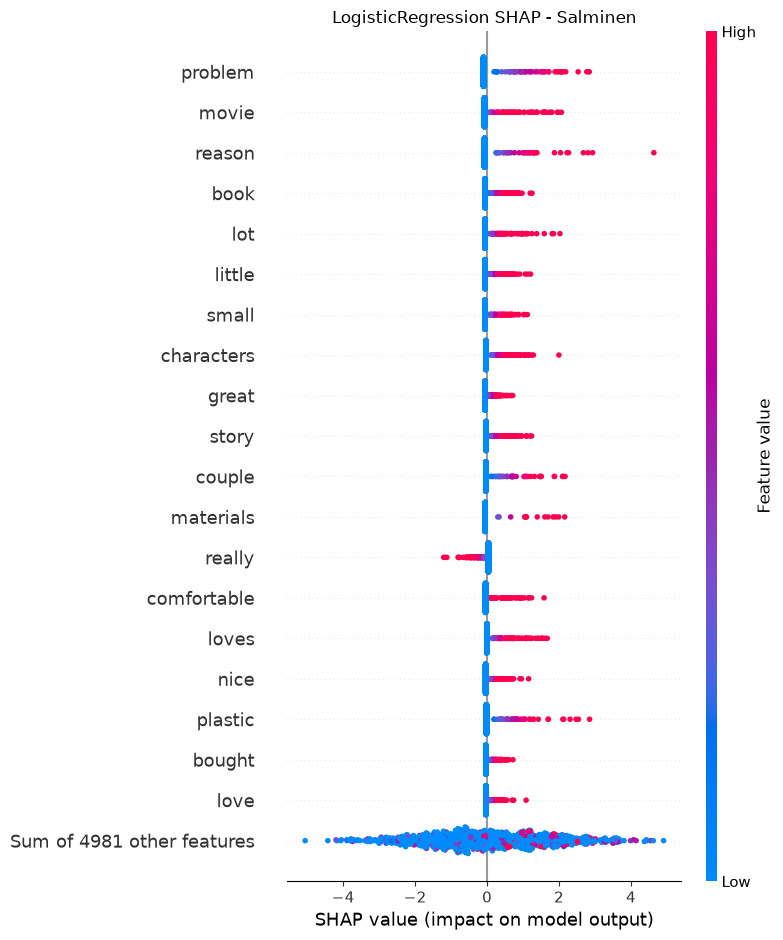

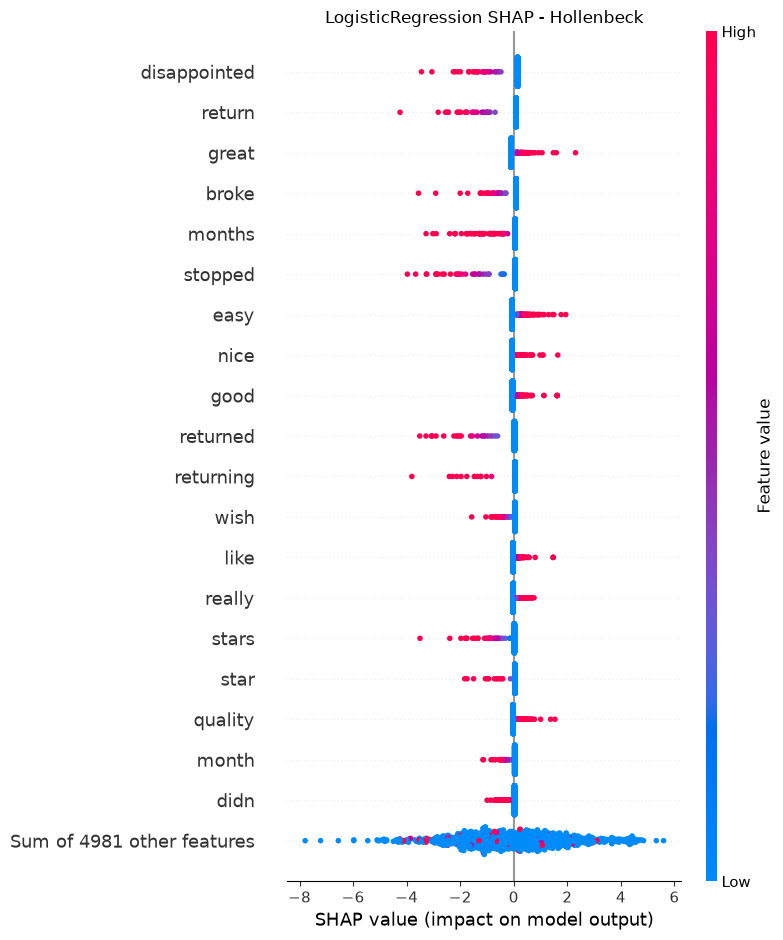

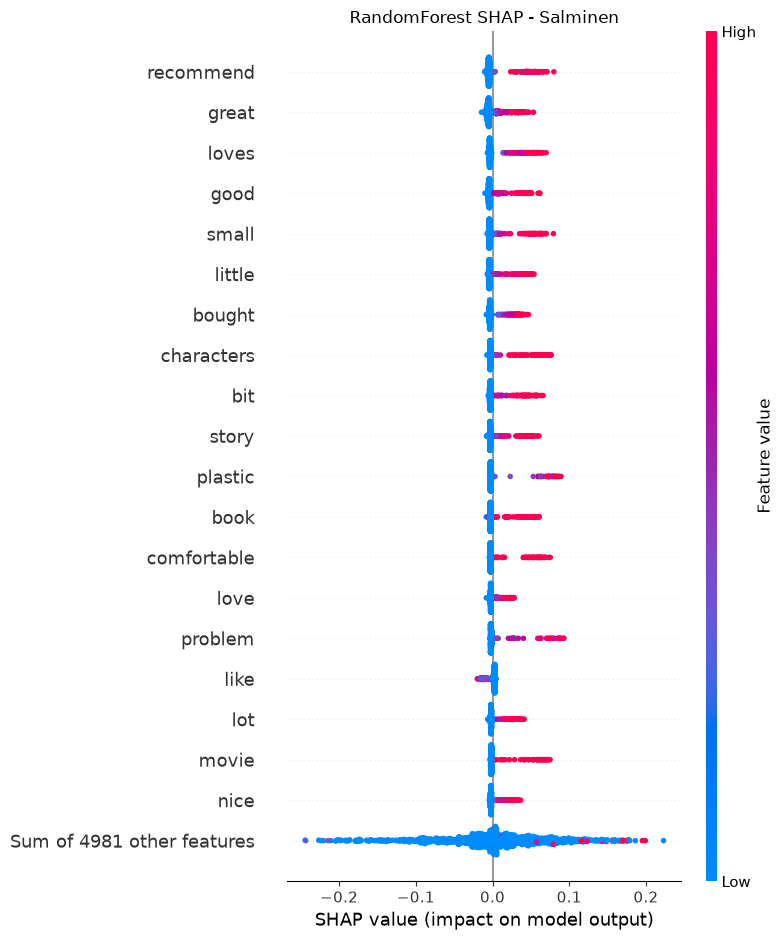

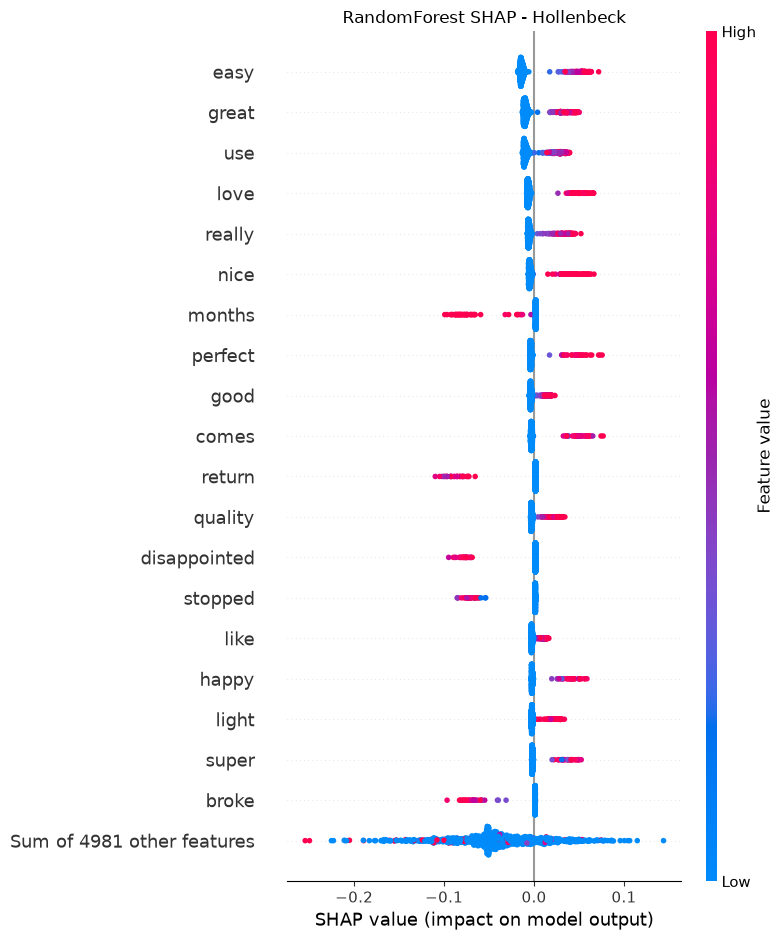

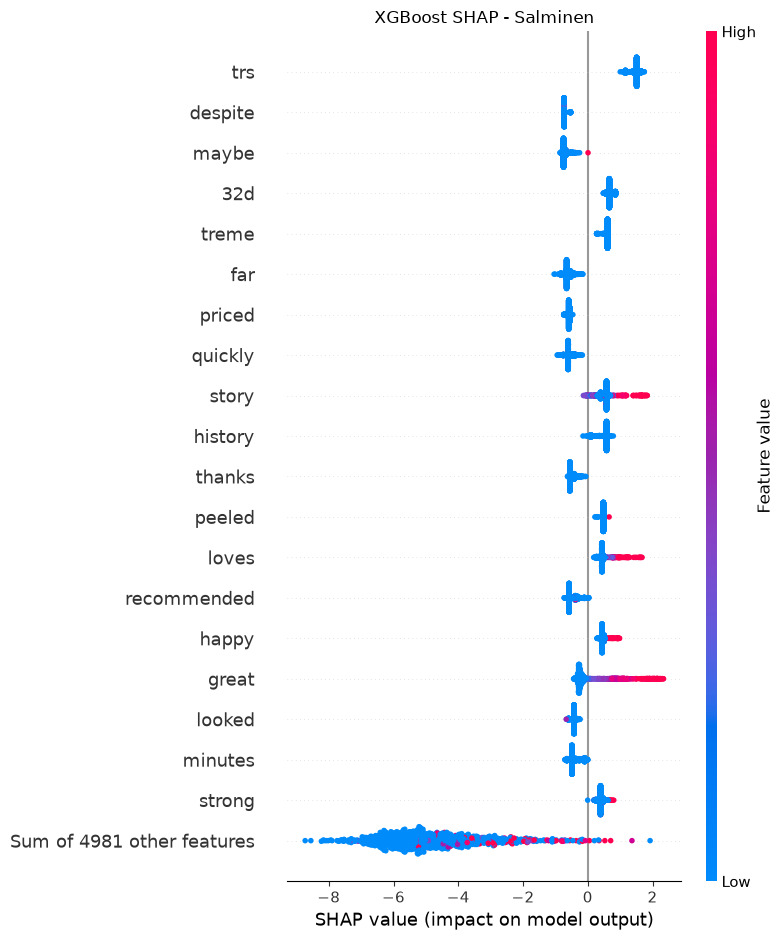

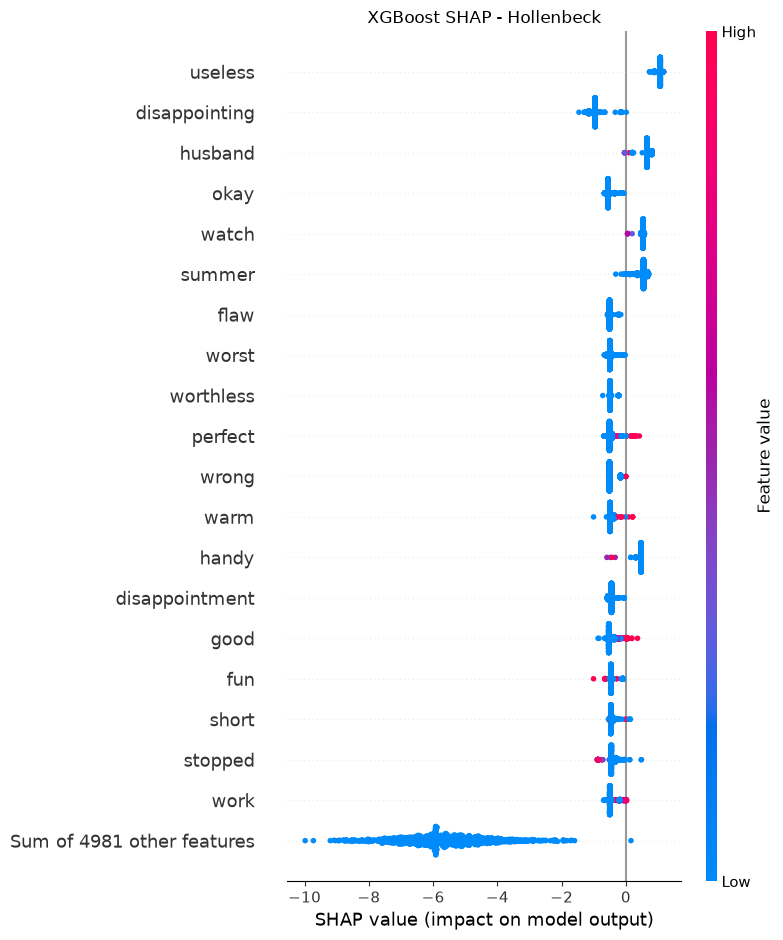

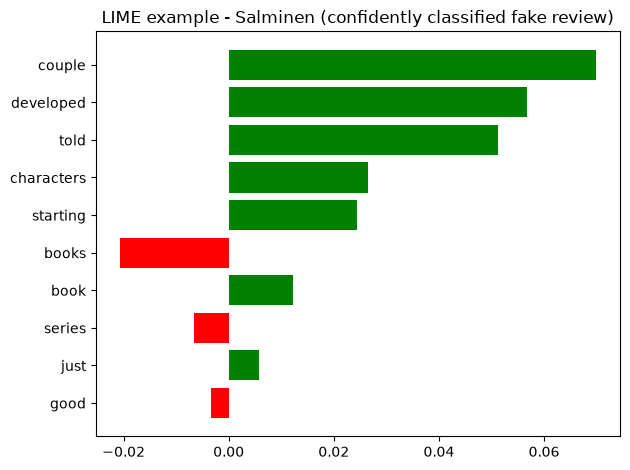

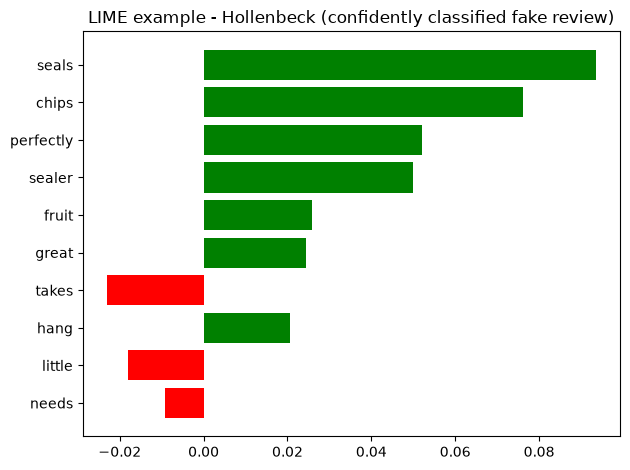

In [9]:
# Define a function to plot SHAP summary plots for each model and dataset
def plot_shap(shap_results, model_name, dataset_name, feature_names):
    sv, sample = shap_results[model_name]
    # Create Explanation object with feature values for colour encoding
    explanation = shap.Explanation(
        values=sv,
        data=sample.toarray(),
        feature_names=list(feature_names)
    )
    shap.plots.beeswarm(explanation, max_display=20, show=False)
    plt.title(f"{model_name} SHAP - {dataset_name}")
    plt.tight_layout()
    model_short = {'LogisticRegression': 'logreg', 'RandomForest': 'rf', 'XGBoost': 'xgboost'}
    plt.savefig(os.path.join(RESULTS_DIR, f"p1_shap_{model_short[model_name]}_{dataset_name.lower()}.png"))
    plt.show()

# Plot SHAP summary plots for each model and dataset
for name in ['LogisticRegression', 'RandomForest', 'XGBoost']:
    plot_shap(salminen_shap, name, "Salminen", salminen_tfidf.get_feature_names_out())
    plot_shap(hollenbeck_shap, name, "Hollenbeck", hollenbeck_tfidf.get_feature_names_out())

# Plot LIME examples for both datasets
salminen_lime[salminen_example_idx].as_pyplot_figure()
plt.title("LIME example - Salminen (confidently classified fake review)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "p1_lime_salminen.png"))
plt.show()

hollenbeck_lime[hollenbeck_example_idx].as_pyplot_figure()
plt.title("LIME example - Hollenbeck (confidently classified fake review)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "p1_lime_hollenbeck.png"))
plt.show()

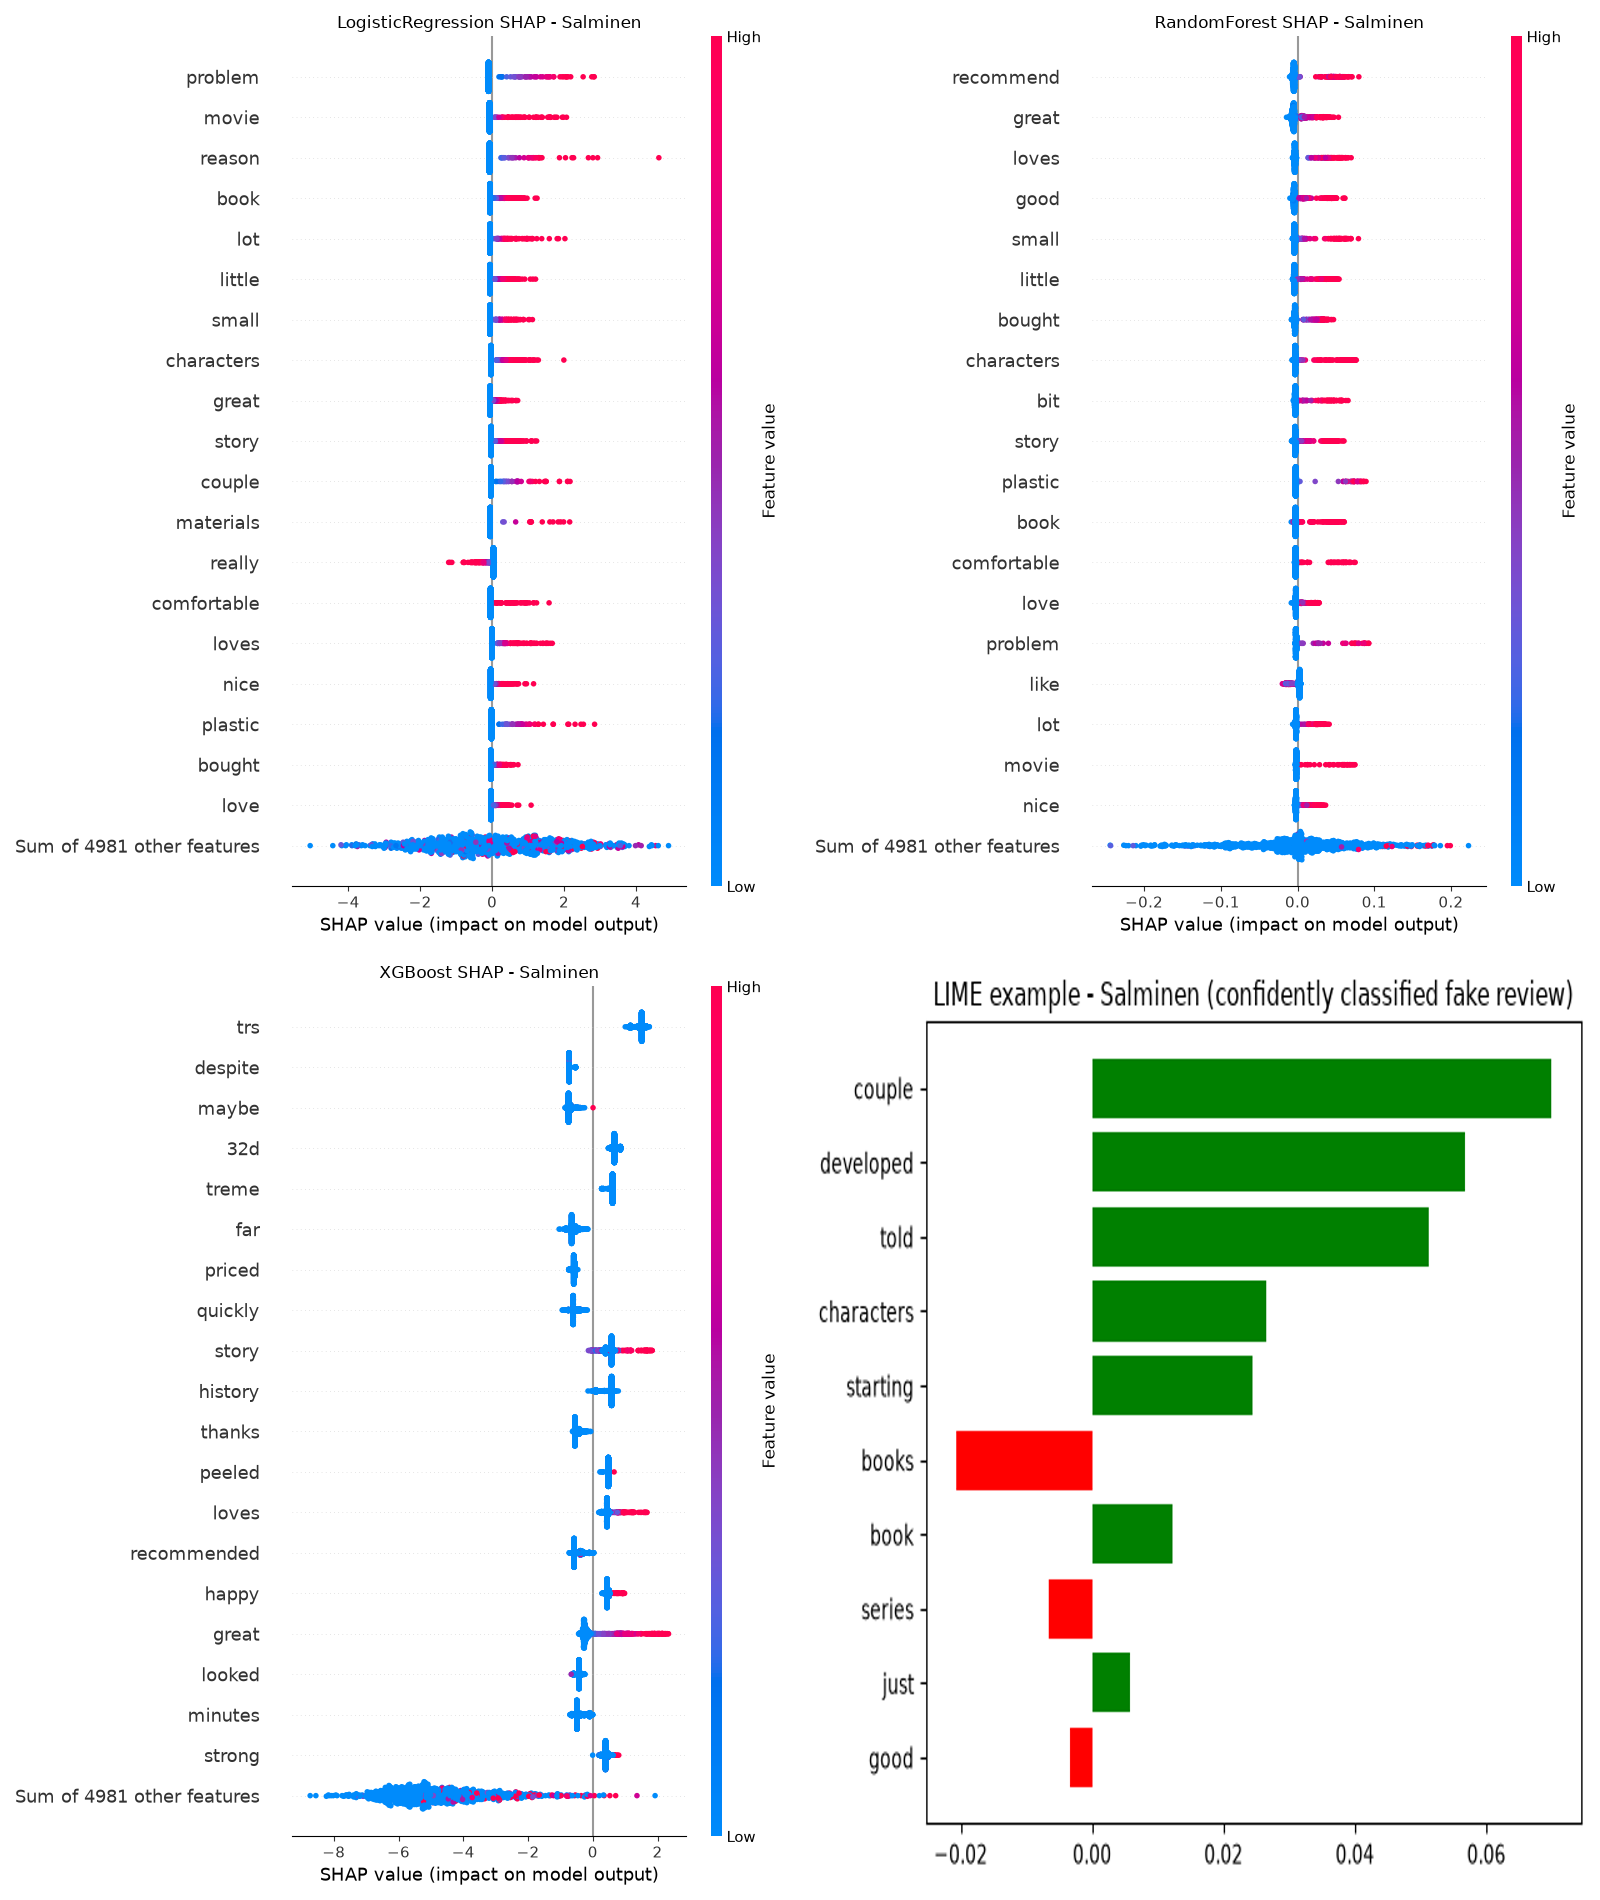

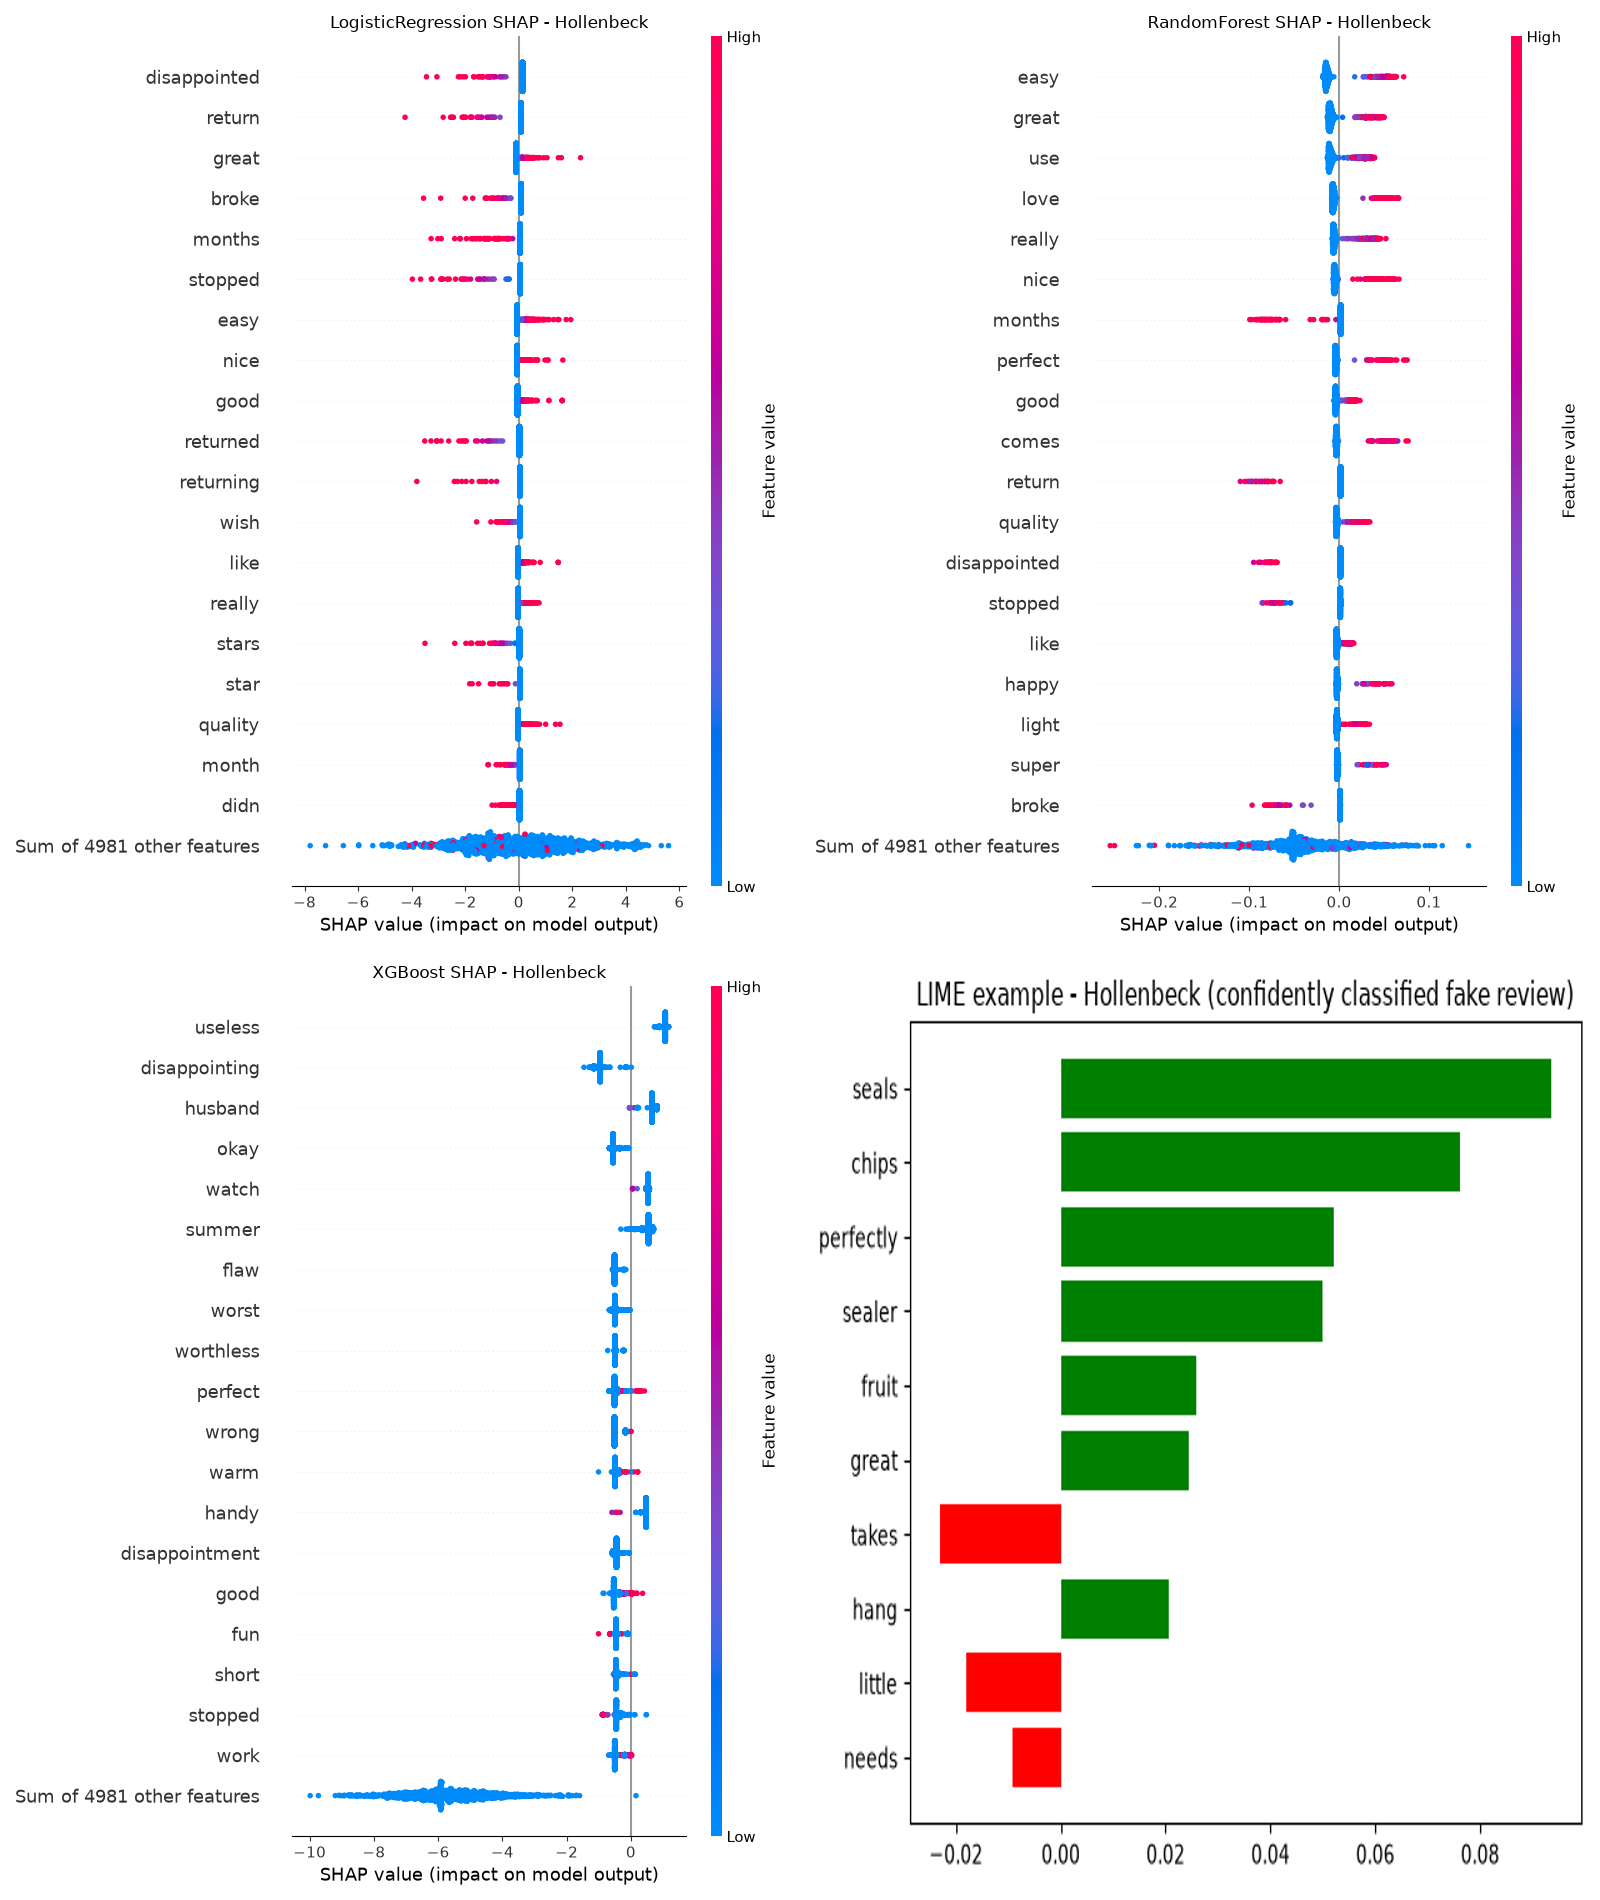

In [10]:
# Combine the SHAP and LIME plots into a single figure for each dataset for presentation in the report
from PIL import Image
import os
from IPython.display import display

results_dir = r'D:\MSC BUSINESS ANALYTICS\Msc project\finalproject\results'

# Salminen dataset
imgs = [
    Image.open(os.path.join(results_dir, 'p1_shap_logreg_salminen.png')),
    Image.open(os.path.join(results_dir, 'p1_shap_rf_salminen.png')),
    Image.open(os.path.join(results_dir, 'p1_shap_xgboost_salminen.png')),
    Image.open(os.path.join(results_dir, 'p1_lime_salminen.png')),
]

w, h = imgs[0].size
imgs = [img.resize((w, h)) for img in imgs]

combined = Image.new('RGB', (w*2, h*2), 'white')
combined.paste(imgs[0], (0, 0))
combined.paste(imgs[1], (w, 0))
combined.paste(imgs[2], (0, h))
combined.paste(imgs[3], (w, h))

combined.save(os.path.join(results_dir, 'p1_combination_salminen.png'))
display(combined)

# Hollenbeck dataset
imgs = [
    Image.open(os.path.join(results_dir, 'p1_shap_logreg_hollenbeck.png')),
    Image.open(os.path.join(results_dir, 'p1_shap_rf_hollenbeck.png')),
    Image.open(os.path.join(results_dir, 'p1_shap_xgboost_hollenbeck.png')),
    Image.open(os.path.join(results_dir, 'p1_lime_hollenbeck.png')),
]

w, h = imgs[0].size
imgs = [img.resize((w, h)) for img in imgs]

combined = Image.new('RGB', (w*2, h*2), 'white')
combined.paste(imgs[0], (0, 0))
combined.paste(imgs[1], (w, 0))
combined.paste(imgs[2], (0, h))
combined.paste(imgs[3], (w, h))

combined.save(os.path.join(results_dir, 'p1_combination_hollenbeck.png'))
display(combined)